When you extract frequent itemsets (words or sets of words that appear together often across your sentences), you reveal underlying structure:

Sentences that share many frequent itemsets are likely to be similar—for example, about the same topic or intent.

This means your sentences can be grouped (clustered) based on how much they “share” these itemsets.

# André

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data

In [219]:
data = pd.read_csv('../data/horoscope_full.csv')

data.columns
#data = data.head(10000)

# this dataset is not real is generated for demonstration purposes only

Index(['ID', 'sign', 'category', 'date', 'horoscope'], dtype='object')

In [220]:
data.rename(columns={'horoscope': 'token'}, inplace=True)

In [221]:
data

,ID,sign,category,date,token
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l..."
1,2,aries,general,20200618,People will understand and appreciate your des...
2,3,aries,general,20200619,You are very interested in technological break...
3,4,aries,general,20200620,Stress from overwork could have you feeling we...
4,5,aries,general,20200621,This is a good day to stand up for yourself an...
...,...,...,...,...,...
21954,21955,pisces,birthday,20210612,Celebrate in style on your birthday in prepara...
21955,21956,pisces,birthday,20210613,Imagine your life as if it was exactly the way...
21956,21957,pisces,birthday,20210614,"Fun, playfulness, and humor are easy to manife..."
21957,21958,pisces,birthday,20210615,"Your birthday brings you a fresh start, as you..."


stats about size of tweets

In [222]:
import re

def clean_keep_apostrophe(text):
    # Only keep letters, digits, apostrophes, and whitespace
    return re.sub(r"[^\w\d'\s]", "", text)

# Apply to your DataFrame
data['token'] = data['token'].apply(clean_keep_apostrophe)
data['token'] = data['token'].str.split()
data["token"] = data["token"].apply(lambda x: [w.lower() for w in x])

In [223]:
data

,ID,sign,category,date,token
0,1,aries,general,20200617,"[there's, a, great, day, ahead, of, you, aries..."
1,2,aries,general,20200618,"[people, will, understand, and, appreciate, yo..."
2,3,aries,general,20200619,"[you, are, very, interested, in, technological..."
3,4,aries,general,20200620,"[stress, from, overwork, could, have, you, fee..."
4,5,aries,general,20200621,"[this, is, a, good, day, to, stand, up, for, y..."
...,...,...,...,...,...
21954,21955,pisces,birthday,20210612,"[celebrate, in, style, on, your, birthday, in,..."
21955,21956,pisces,birthday,20210613,"[imagine, your, life, as, if, it, was, exactly..."
21956,21957,pisces,birthday,20210614,"[fun, playfulness, and, humor, are, easy, to, ..."
21957,21958,pisces,birthday,20210615,"[your, birthday, brings, you, a, fresh, start,..."


In [224]:
data["original_token_size"] = data["token"].apply(len)
data["original_token_size"].describe()

count    21959.000000
mean        72.557357
std         20.399072
min         32.000000
25%         61.000000
50%         69.000000
75%         85.000000
max        175.000000
Name: original_token_size, dtype: float64

In [225]:
"""# Count "you" in each row and make a new column
data["count_you"] = data["token"].apply(lambda x: x.count("you"))

# Print the result per row
print(data[["token", "count_you"]])

# Get the total count over all rows
total_you = data["count_you"].sum()
print(data[data["count_you"] != 0].shape)"""


'# Count "you" in each row and make a new column\ndata["count_you"] = data["token"].apply(lambda x: x.count("you"))\n\n# Print the result per row\nprint(data[["token", "count_you"]])\n\n# Get the total count over all rows\ntotal_you = data["count_you"].sum()\nprint(data[data["count_you"] != 0].shape)'

# Word Data (Counter)

In [207]:
data["original_sentence"] = data["token"]
longer_data = data.explode('token').rename(columns={'token': 'word'})
longer_data['word'] = longer_data['word'].str.lower()

longer_data

,ID,sign,category,date,word,original_token_size,original_sentence
0,1,aries,general,20200617,there's,61,"[there's, a, great, day, ahead, of, you, aries..."
0,1,aries,general,20200617,a,61,"[there's, a, great, day, ahead, of, you, aries..."
0,1,aries,general,20200617,great,61,"[there's, a, great, day, ahead, of, you, aries..."
0,1,aries,general,20200617,day,61,"[there's, a, great, day, ahead, of, you, aries..."
0,1,aries,general,20200617,ahead,61,"[there's, a, great, day, ahead, of, you, aries..."
...,...,...,...,...,...,...,...
21958,21959,pisces,birthday,20210616,that,121,"[you, will, probably, enjoy, being, the, cente..."
21958,21959,pisces,birthday,20210616,comes,121,"[you, will, probably, enjoy, being, the, cente..."
21958,21959,pisces,birthday,20210616,naturally,121,"[you, will, probably, enjoy, being, the, cente..."
21958,21959,pisces,birthday,20210616,to,121,"[you, will, probably, enjoy, being, the, cente..."


In [208]:
word_counter = longer_data['word'].value_counts().reset_index()
word_counter.columns = ['word', 'count']

# Show the counts
word_counter.head(50)

,word,count
0,you,75852
1,to,57961
2,and,57960
3,the,50712
4,your,40128
5,a,39873
6,in,35492
7,of,29046
8,be,27588
9,is,19255


In [209]:
word_counter_sorted = word_counter.sort_values(by='count', ascending=False)

57


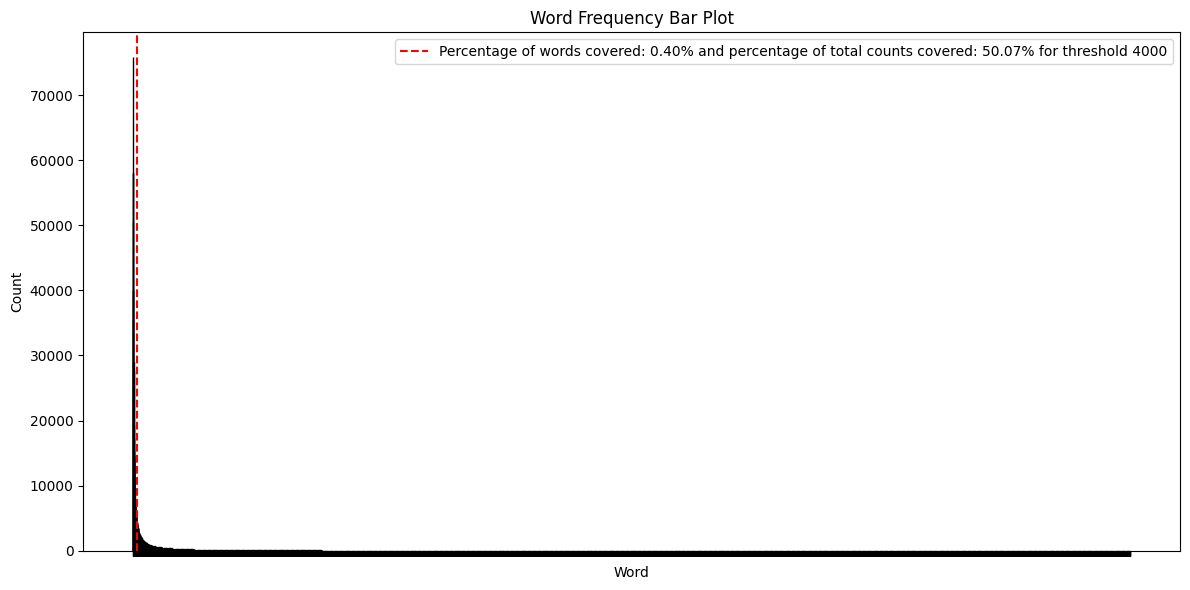

In [210]:
import matplotlib.pyplot as plt

# Assume word_counter is a DataFrame with columns 'word' and 'count'
# Sort by count descending (if not already sorted)
word_counter_sorted = word_counter.sort_values(by='count', ascending=False)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot: Words on x-axis, counts on y-axis
ax.bar(
    word_counter_sorted['word'],
    word_counter_sorted['count'],
    color='skyblue',
    edgecolor='black'
)

# Title and axis labels (use ax.set_*, not ax.*)
ax.set_title('Word Frequency Bar Plot')
ax.set_xlabel('Word')
ax.set_ylabel('Count')
ax.set_xticklabels([])

# Rotate x-tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Draw a vertical line at the 10th bar (adjust as needed)
thresholds = [4000]  # Example thresholds
positions = [
    word_counter_sorted[word_counter_sorted['count'] < y].index[0] for y in thresholds
]

for xpos, yval in zip(positions, thresholds):
    print(xpos)
    all_words_len = word_counter_sorted['count'].sum()
    covered_words_len = word_counter_sorted['count'][:xpos].sum()
    percentage_words_covered = (covered_words_len/all_words_len)*100
    ax.axvline(
        x=xpos - 0.5,
        color='red',
        linestyle='--',
        label=f'Percentage of words covered: {(xpos/len(word_counter_sorted))*100:.2f}% and percentage of total counts covered: {percentage_words_covered:.2f}% for threshold {yval}'
    )

# Show legend
ax.legend()

# Adjust layout to fit labels
fig.tight_layout()
plt.show()


# Itemsets

In [230]:
import pandas as pd
from collections import Counter
from itertools import combinations

# ----- SETUP -----
min_support = 0.02
max_k = 4                 # PCY classic: 1 and 2 only
num_buckets = 1000       # Tune depending on dataset size/RAM

# -- transactions: list of lists of unique items --
transactions = [list(dict.fromkeys(t)) for t in data['token'].tolist()]
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

# ---- PASS 1: Count items and hash buckets ----
single_counts = Counter()
hash_buckets = [0] * num_buckets

for t in transactions:
    items = set(t)
    single_counts.update(items)
    # Hash each pair into a bucket
    for comb in combinations(sorted(items), 2):
        bucket_id = hash(comb) % num_buckets
        hash_buckets[bucket_id] += 1

# ---- Bitmap: Frequent buckets ----
bucket_bitmap = [0] * num_buckets
for b in range(num_buckets):
    if hash_buckets[b] / num_tx >= min_support:
        bucket_bitmap[b] = 1

# ---- Frequent singles ----
freq_items = {item for item, cnt in single_counts.items() if cnt / num_tx >= min_support}
results = []
for item in freq_items:
    support = single_counts[item] / num_tx
    results.append({'itemset': (item,), 'count': single_counts[item], 'support': support, 'k': 1})

# ---- PASS 2: Count candidate pairs ----
pair_counts = Counter()
for t in transactions:
    items = [item for item in set(t) if item in freq_items]
    for comb in combinations(sorted(items), 2):
        bucket_id = hash(comb) % num_buckets
        if bucket_bitmap[bucket_id]:
            pair_counts[comb] += 1

# ---- Frequent pairs ----
for pair, cnt in pair_counts.items():
    support = cnt / num_tx
    if support >= min_support:
        results.append({'itemset': pair, 'count': cnt, 'support': support, 'k': 2})

# ---- Results DataFrame ----
freq_itemsets_df = pd.DataFrame(results)
freq_itemsets_df = freq_itemsets_df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)

print('\nTop itemsets by support:')
freq_itemsets_df

# Optional: save to CSV
# freq_itemsets_df.to_csv('frequent_itemsets_pcy.csv', index=False)


Number of transactions: 21959

Top itemsets by support:


,itemset,count,support,k
0,"(you,)",21365,0.972950,1
1,"(to,)",20478,0.932556,1
2,"(the,)",19599,0.892527,1
3,"(and,)",18769,0.854729,1
4,"(your,)",18325,0.834510,1
...,...,...,...,...
9241,"(chance, may)",440,0.020037,2
9242,"(light, to)",440,0.020037,2
9243,"(could, current)",440,0.020037,2
9244,"(love, very)",440,0.020037,2


In [ ]:
# Find frequent itemsets (count-based, no external libraries)
# Configurable parameters
min_support = 0.02   # minimum support (fraction of transactions)
max_k = 3           # maximum size of itemsets to search (1..max_k)

In [162]:
max_k = 3
min_support = 0.02

In [ ]:
from collections import Counter
from itertools import combinations

# Prepare transactions: list of token lists (unique items per sentence)
transactions = [list(dict.fromkeys(t)) for t in data['token'].tolist()] # List of lists of unique items in a sentence
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

def get_frequent_itemsets(transactions, max_k, min_support):
    n = len(transactions)
    results = []  # list of dicts: {'itemset': tuple, 'count': int, 'support': float}

    # Count single items
    single_counts = Counter() # Count of single items across all sentences
    for t in transactions:
        single_counts.update(set(t)) # Count unique items trough each sentence

    # collect frequent 1-itemsets
    prev_freq = {}
    for item, cnt in single_counts.items():
        support = cnt / n
        if support >= min_support:
            results.append({'itemset': (item,), 'count': cnt, 'support': support})
            prev_freq[(item,)] = cnt

    print("single_counts done")
    # iterate for k = 2..max_k
    k = 2
    while k <= max_k and prev_freq: # continue while we have frequent itemsets of size k-1
        candidate_counts = Counter() # candidate itemsets of size k
        for t in transactions: # for each sentence
            items = sorted(set(t)) # unique items in sentence
            if len(items) < k: #
                continue
            for comb in combinations(items, k): # generate combinations of size k
                candidate_counts[comb] += 1 

        # filter by min_support
        freq_k = {}
        for comb, cnt in candidate_counts.items(): # for each candidate itemset calculate support
            support = cnt / n
            if support >= min_support:
                results.append({'itemset': comb, 'count': cnt, 'support': support})
                freq_k[comb] = cnt

        prev_freq = freq_k
        k += 1

    # return results as DataFrame sorted by k and support desc
    if not results:
        return pd.DataFrame(columns=['itemset','count','support','k'])

    df = pd.DataFrame(results)
    df['k'] = df['itemset'].apply(len)
    df = df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)
    return df

# Run the mining
freq_itemsets_df = get_frequent_itemsets(transactions, max_k= max_k, min_support= min_support)

# Optional: save to CSV
# freq_itemsets_df.to_csv('../data/frequent_itemsets.csv', index=False)

# Quick summary: top itemsets by support
print('\nTop itemsets by support:')
print(freq_itemsets_df.head(20))

Number of transactions: 21959


,itemset,count,support,k
0,"(you,)",20801,0.947265,1
1,"(to,)",20456,0.931554,1
2,"(the,)",18779,0.855185,1
3,"(and,)",18738,0.853318,1
4,"(your,)",17633,0.802996,1
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3



Top itemsets by support:
    itemset  count   support  k
0    (you,)  20801  0.947265  1
1     (to,)  20456  0.931554  1
2    (the,)  18779  0.855185  1
3    (and,)  18738  0.853318  1
4   (your,)  17633  0.802996  1
5      (a,)  17525  0.798078  1
6     (of,)  16133  0.734687  1
7     (in,)  14662  0.667699  1
8     (be,)  13601  0.619382  1
9     (is,)  12474  0.568059  1
10  (that,)  11794  0.537092  1
11  (with,)  10429  0.474931  1
12   (for,)  10188  0.463956  1
13   (You,)  10070  0.458582  1
14  (will,)   9965  0.453800  1
15   (may,)   9860  0.449019  1
16   (are,)   9406  0.428344  1
17  (this,)   8937  0.406986  1
18    (it,)   8935  0.406895  1
19  (have,)   8570  0.390273  1


# Analysis of result of itemsets

In [17]:
# Show only 1-itemsets (k == 1). Use a safe check in case the 'k' column is missing.
if 'k' in freq_itemsets_df.columns:
    display(freq_itemsets_df[freq_itemsets_df['k'] != 1])
else:
    print("DataFrame has no 'k' column. Available columns:", freq_itemsets_df.columns.tolist())

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3


In [160]:
# Exclude certain words from the itemset table (simple and editable)
# Edit this set to exclude words from the results (lowercase)

"""excluded_words = must come from TF IDF"""
excluded_words = ["you"]

# helper: return True if any word in itemset is in excluded_words
def itemset_has_excluded(itemset, excluded):
    return any(word in excluded for word in itemset)

if 'itemset' in globals() or 'freq_itemsets_df' in globals():
    if 'freq_itemsets_df' in globals() and 'itemset' in freq_itemsets_df.columns:
        filtered_itemsets = freq_itemsets_df[~freq_itemsets_df['itemset'].apply(lambda it: itemset_has_excluded(it, excluded_words))]
        print(f"Excluded words: {sorted(list(excluded_words))}")
        print(f"Original itemsets: {len(freq_itemsets_df)}  →  After exclusion: {len(filtered_itemsets)}")
        display(filtered_itemsets)

    else:
        print("`freq_itemsets_df` not available or has no 'itemset' column. Run the mining cell first.")
else:
    print("Frequent itemset DataFrame not found in the notebook namespace.")


Frequent itemset DataFrame not found in the notebook namespace.


In [19]:
# Show only 1-itemsets (k == 1) — placed after the latest code blocks
# This safely checks for the 'k' column and displays only 1-itemsets.
if 'filtered_itemsets' in globals():
    if 'k' in filtered_itemsets.columns:
        display(filtered_itemsets[filtered_itemsets['k'] == 2])
    else:
        print("DataFrame has no 'k' column. Available columns:", filtered_itemsets.columns.tolist())
else:
    print("`freq_itemsets_df` not found. Run the frequent-itemset mining cell first.")

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
9212,"(it, special)",440,0.020037,2
9213,"(current, today)",440,0.020037,2
9214,"(will, would)",440,0.020037,2
9215,"(and, late)",440,0.020037,2
